# DATA ANALISI CANZONI SPOTIFY

In [1]:
import pandas as pd
#pd.set_option('display.max_rows', None)
import numpy as np
import statistics as st
import matplotlib.pyplot as plt
print('Pandas:', pd.__version__)
print('NumPy: ', np.__version__)

Pandas: 3.0.2
NumPy:  2.4.4


## EDA
EDA (Exploratory Data Analysis, ovvero Analisi Esplorativa dei Dati) è la fase iniziale di qualsiasi progetto di data analysis, in cui si esaminano i dati grezzi per capirne la struttura, scoprire pattern e identificare anomalie — prima di applicare qualsiasi modello statistico o di machine learning.
### Obiettivi principali
- Comprendere la struttura del dataset: distribuzione delle variabili, tipi di dati, dimensioni
- Individuare valori mancanti e outlier: errori, dati nulli o valori anomali che potrebbero falsare le analisi
- Scoprire relazioni tra variabili: correlazioni e pattern nascosti nei dati
- Formulare ipotesi: generare domande di ricerca da verificare nelle fasi successive
- Ridurre i bias: identificare distorsioni nei dati per garantire analisi più accurate


## 1. La struttura del dataset: distribuzione delle variabili, tipi di dati, dimensioni
### 1.1.  Dimensioni del dataset: quante righe (osservazioni) e quante colonne (variabili).

In [2]:
dfspotify=pd.read_csv('spotify.csv', sep=";")
dfspotifymanipulation=dfspotify.copy() #CREO UNA COPIA PROFONDA DEL DATASET ORIGINALE

In [3]:
dfspotify.head(10)

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_name & track name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,anno,decade,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4.0,0.0,True,Diplo,Diplo - Trippy Mane (ft. Project Pat),77.0,"2812821,00",moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,2025,2020,9.0,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1.0,0.0,True,Yelawolf,Yelawolf - OMG!,64.0,"2363438,00","country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,2025,2020,1.0,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1.0,4.0,True,Riff Raff,Riff Raff - Hard 2 Find,48.0,"193302,00",NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,2025,2020,1.0,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8.0,30.0,True,Diplo,Diplo - Still Get Like That (ft. Project Pat &...,77.0,"2813710,00",moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,2025,2020,9.0,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2.0,0.0,True,Rumelis,Rumelis - ride me like a harley,48.0,"8682,00",dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2025,2020,2.0,single,2.39
5,4ccpCcZYseq8VrPMK1EDs0,BLEED,1.0,2.0,False,Minzie,Minzie - BLEED,46.0,"7218,00",dark r&b,2NQv9p3ZQW0Ed1LB9enix8,BLEED,2025-10-30,2025,2020,3.0,single,2.76
6,3QoQ3HqXTAjgEl9LbNMbYp,Te Procuro na Cidade,1.0,20.0,False,AZERDK,AZERDK - Te Procuro na Cidade,30.0,"1657,00",NaN,1PpuOsLjPWshDLxkr0oHeU,Te Procuro na Cidade,2025-10-30,2025,2020,1.0,single,4.12
7,1YEZbdT417SfolPQzaoHs2,come closer,1.0,27.0,False,Rumelis,Rumelis - come closer,49.0,"8802,00",dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2025,2020,2.0,single,2.53
8,4pZ949nFW5SurwzE0TSe7I,Cupido Vagabundo,1.0,16.0,False,Toni dos Anjos,Toni dos Anjos - Cupido Vagabundo,6.0,"475,00",NaN,60DLQZkzpvDvVfvEC6VOJM,Cupido Vagabundo,2025-10-30,2025,2020,2.0,single,2.92
9,0L0LgwFZ7UtBnRNQvSBty6,LET’S GO!,1.0,33.0,True,PsychoYP,PsychoYP - LET’S GO!,48.0,"154802,00","nigerian drill, alté, afro adura, afrobeats, a...",3ARxksm8CspGeAaZZB1v2w,LET’S GO!,2025-10-28,2025,2020,1.0,single,2.40


In [4]:
dfspotify.tail(5)

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_name & track name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,anno,decade,album_total_tracks,album_type,track_duration_min
8577,0AQquaENerGps8BQmbPw14,Big Iron,1.0,71.0,False,Marty Robbins,Marty Robbins - Big Iron,60.0,"626733,00","classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,1959,1950,15.0,album,3.92
8578,4f8hBeMXMvssn6HtFAtblo,El Paso,10.0,64.0,False,Marty Robbins,Marty Robbins - El Paso,61.0,"626733,00","classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,1959,1950,15.0,album,4.32
8579,0Vy7wsXNFrbNc6UTWoScnM,Over the Rainbow,5.0,8.0,False,The Mystics,The Mystics - Over the Rainbow,27.0,"18184,00",doo-wop,2ifB9Xjp9DdpqLlYlY60QW,Presenting The Mystics,1959-02-11,1959,1950,9.0,compilation,2.28
8580,760clbeDBWmBsBLbszWuNZ,I'm A Man,2.0,55.0,False,Bo Diddley,Bo Diddley - I'm A Man,44.0,"333376,00","blues, classic blues, rock and roll, rockabilly",1cbtDEwxCjMhglb49OgNBR,Bo Diddley,1958-01-01,1958,1950,12.0,album,2.74
8581,61GEP8lryEfcuEgBMbRmNi,Alone And Forsaken,11.0,45.0,False,Hank Williams,Hank Williams - Alone And Forsaken,55.0,"1067339,00","classic country, honky tonk, traditional count...",3cusZESjkIDnDXyQwbpSsT,Moanin' The Blues (Expanded Edition),1952-09-12,1952,1950,12.0,album,2.02


Il file è composto da 8582 righe divise in 18 colonne.

In [5]:
dfspotify.shape #(righe, colonne)

(8582, 18)

Le colonne del DataFrame sono:

In [6]:
dfspotify.columns # lista dei nomi delle colonne

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'explicit', 'artist_name', 'artist_name & track name',
       'artist_popularity', 'artist_followers', 'artist_genres', 'album_id',
       'album_name', 'album_release_date', 'anno', 'decade',
       'album_total_tracks', 'album_type', 'track_duration_min'],
      dtype='str')

### 1.2. Struttura e tipi di dati


In [7]:
dfspotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  8582 non-null   str    
 1   track_name                8582 non-null   str    
 2   track_number              8579 non-null   float64
 3   track_popularity          8579 non-null   float64
 4   explicit                  8579 non-null   object 
 5   artist_name               8576 non-null   str    
 6   artist_name & track name  8582 non-null   str    
 7   artist_popularity         8578 non-null   float64
 8   artist_followers          8578 non-null   str    
 9   artist_genres             5220 non-null   str    
 10  album_id                  8578 non-null   str    
 11  album_name                8578 non-null   str    
 12  album_release_date        8571 non-null   str    
 13  anno                      8582 non-null   int64  
 14  decade             

In [8]:
dfspotify.dtypes

track_id                        str
track_name                      str
track_number                float64
track_popularity            float64
explicit                     object
artist_name                     str
artist_name & track name        str
artist_popularity           float64
artist_followers                str
artist_genres                   str
album_id                        str
album_name                      str
album_release_date              str
anno                          int64
decade                        int64
album_total_tracks          float64
album_type                      str
track_duration_min          float64
dtype: object

### 1.3. Distribuzione delle variabili numeriche
Per le colonne numeriche, le statistiche descrittive riassumono la distribuzione: centro, dispersione ed estremi.

df.describe() calcola automaticamente per ogni colonna numerica:

- count → quanti valori non nulli

- mean → media

- std → deviazione standard (quanto i valori si discostano dalla media)

- min / max → valore minimo e massimo

- 25%, 50%, 75% → percentili (quartili)

In [9]:
dfspotify.describe()

,track_number,track_popularity,artist_popularity,anno,decade,album_total_tracks,track_duration_min
count,8579.000000,8579.000000,8578.000000,8582.000000,8582.000000,8571.000000,8571.000000
mean,5.773284,52.362513,69.734670,2014.909578,2010.673503,13.791856,3.493214
std,6.053311,23.810823,19.641518,10.862898,11.210954,11.891088,1.057737
min,1.000000,0.000000,0.000000,1900.000000,1900.000000,1.000000,0.070000
25%,1.000000,39.000000,60.000000,2012.000000,2010.000000,6.000000,2.880000
50%,4.000000,58.000000,74.000000,2018.000000,2010.000000,13.000000,3.450000
75%,9.000000,71.000000,84.000000,2022.000000,2020.000000,17.000000,3.990000
max,102.000000,99.000000,100.000000,2025.000000,2020.000000,181.000000,13.510000


Per includere anche le colonne non numeriche:

In [10]:
dfspotify.describe(include='all')

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_name & track name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,anno,decade,album_total_tracks,album_type,track_duration_min
count,8582,8582,8579.000000,8579.000000,8579,8576,8582,8578.000000,8578,5220,8578,8578,8571,8582.000000,8582.000000,8571.000000,8571,8571.000000
unique,8582,7462,NaN,NaN,2,2546,7923,NaN,3739,661,5202,4867,2382,NaN,NaN,NaN,3,NaN
top,3EJS5LyekDim1Tf5rBFmZl,Flowers,NaN,NaN,False,Taylor Swift,Taylor Swift - Wildest Dreams,NaN,"145396321,00",soundtrack,3FFGbUutKWN1c4f0CJR4Uh,Nevermind (Super Deluxe Edition),2010-01-01,NaN,NaN,NaN,album,NaN
freq,1,8,NaN,NaN,6431,324,5,NaN,137,345,70,70,76,NaN,NaN,NaN,5848,NaN
mean,NaN,NaN,5.773284,52.362513,NaN,NaN,NaN,69.734670,NaN,NaN,NaN,NaN,NaN,2014.909578,2010.673503,13.791856,NaN,3.493214
std,NaN,NaN,6.053311,23.810823,NaN,NaN,NaN,19.641518,NaN,NaN,NaN,NaN,NaN,10.862898,11.210954,11.891088,NaN,1.057737
min,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,1900.000000,1900.000000,1.000000,NaN,0.070000
25%,NaN,NaN,1.000000,39.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,2012.000000,2010.000000,6.000000,NaN,2.880000
50%,NaN,NaN,4.000000,58.000000,NaN,NaN,NaN,74.000000,NaN,NaN,NaN,NaN,NaN,2018.000000,2010.000000,13.000000,NaN,3.450000
75%,NaN,NaN,9.000000,71.000000,NaN,NaN,NaN,84.000000,NaN,NaN,NaN,NaN,NaN,2022.000000,2020.000000,17.000000,NaN,3.990000


### 1.4. Distribuzione delle variabili categoriche
Per le variabili di tipo testo o categoria, invece di media e deviazione standard, conti le frequenze.


#### artist_name

In [11]:
dfspotify['artist_name'].value_counts() #conto frequenze ovvero conto valori unici


artist_name
Taylor Swift     324
The Weeknd       141
Lana Del Rey      99
Ariana Grande     94
Nirvana           91
                ... 
Dick Dale          1
Chuck Berry        1
The Mystics        1
Bo Diddley         1
Hank Williams      1
Name: count, Length: 2546, dtype: int64

In [12]:
dfspotify['artist_name'].value_counts(normalize=True) # in percentuale

artist_name
Taylor Swift     0.037780
The Weeknd       0.016441
Lana Del Rey     0.011544
Ariana Grande    0.010961
Nirvana          0.010611
                   ...   
Dick Dale        0.000117
Chuck Berry      0.000117
The Mystics      0.000117
Bo Diddley       0.000117
Hank Williams    0.000117
Name: proportion, Length: 2546, dtype: float64

In [13]:
dfspotify['artist_name'].nunique() #quanti valori distinti (unici) esistono

2546

In [14]:
dfspotify['artist_name'].unique() #quali sono i valori unici

<StringArray>
[                 'Diplo',               'Yelawolf',              'Riff Raff',
                'Rumelis',                 'Minzie',                 'AZERDK',
         'Toni dos Anjos',               'PsychoYP',  'What Matters The Most',
                    'A2O',
 ...
              'Link Wray',            'Ben E. King', 'Booker T. & the M.G.'s',
           'Quincy Jones',              'Dick Dale',            'Chuck Berry',
          'Marty Robbins',            'The Mystics',             'Bo Diddley',
          'Hank Williams']
Length: 2547, dtype: str

#### artist_genres	

In [15]:
dfspotify['artist_genres'].value_counts()

artist_genres
soundtrack                                                                                      345
pop                                                                                             326
country, pop, indie, folk                                                                       324
soft pop                                                                                        199
rap                                                                                             187
                                                                                               ... 
motown, classic soul, soul                                                                        1
soul jazz, big band, quiet storm                                                                  1
rockabilly, rock and roll                                                                         1
blues, classic blues, rock and roll, rockabilly                                       

In [16]:
dfspotify['artist_genres'].value_counts(normalize=True)

artist_genres
soundtrack                                                                                      0.066092
pop                                                                                             0.062452
country, pop, indie, folk                                                                       0.062069
soft pop                                                                                        0.038123
rap                                                                                             0.035824
                                                                                                  ...   
motown, classic soul, soul                                                                      0.000192
soul jazz, big band, quiet storm                                                                0.000192
rockabilly, rock and roll                                                                       0.000192
blues, classic blues, rock and roll, rock

In [17]:
dfspotify['artist_genres'].unique()

<StringArray>
[                                                                                  'moombahton',
                                                            'country hip hop, southern hip hop',
                                                                                            nan,
                                                                                     'dark r&b',
                             'nigerian drill, alté, afro adura, afrobeats, afrobeat, afroswing',
                                                                                        'c-pop',
                                                                                'pop punk, emo',
                                                                                   'slap house',
                                                                       'neo-psychedelic, indie',
                                                                                  'hypertechno',
 ...
           

In [18]:
dfspotify['artist_genres'].nunique()

661

## 2. Individuare valori mancanti e outlier: errori, dati nulli o valori anomali che potrebbero falsare le analisi
### 2.1. Valori mancanti (NaN / Null)

#### 2.1.1. Rivelazione dati mancanti

In [19]:
dfspotify.isnull() # → DataFrame booleano (True dove il valore è NaN)

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_name & track name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,anno,decade,album_total_tracks,album_type,track_duration_min
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8577,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8578,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8579,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8580,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [20]:
dfspotify.isnull().sum() #→ conta i NaN per ogni colonna

track_id                       0
track_name                     0
track_number                   3
track_popularity               3
explicit                       3
artist_name                    6
artist_name & track name       0
artist_popularity              4
artist_followers               4
artist_genres               3362
album_id                       4
album_name                     4
album_release_date            11
anno                           0
decade                         0
album_total_tracks            11
album_type                    11
track_duration_min            11
dtype: int64

#### 1.1.2. Come gestire i valori mancanti

Elimino le righe dove il artist_name è NaN

In [21]:
dfspotifymanipulation.dropna(subset=['artist_name'], inplace=True) # elimina solo se NaN in quella colonna

In [22]:
dfspotifymanipulation.shape

(8576, 18)

In [23]:
dfspotifymanipulation.dropna(subset=['album_id','album_name'], inplace=True)

In [24]:
dfspotifymanipulation.shape

(8575, 18)

## 3. Scoprire relazioni tra variabili: correlazioni e pattern nascosti nei dati
Questa fase EDA serve a capire se — e quanto — due o più variabili si influenzano a vicenda, rivelando pattern nascosti nei dati.

### 3.1. Matrice di correlazione (solo se esiste)
#### CORRELAZIONE 
La correlazione misura la forza e la direzione della relazione lineare tra due variabili numeriche. 
Il coefficiente r varia sempre tra -1 e +1:

Valore di r	Significato
- r = +1	Correlazione positiva perfetta (entrambe crescono insieme)
- r = -1	Correlazione negativa perfetta (una cresce, l'altra scende)
- r = 0	Nessuna relazione lineare
- 0.5 < r < 0.8	Correlazione positiva moderata
- -0.5 > r > -0.8	Correlazione negativa moderata


In [25]:
#SELEZIONE SOLO DELLE COLONNE NUMERICHE
dfspotifymanipulationNUMERIC=dfspotifymanipulation.select_dtypes(include='number')

In [26]:
dfspotifymanipulationNUMERIC.head(10)

,track_number,track_popularity,artist_popularity,anno,decade,album_total_tracks,track_duration_min
0,4.0,0.0,77.0,2025,2020,9.0,1.55
1,1.0,0.0,64.0,2025,2020,1.0,3.07
2,1.0,4.0,48.0,2025,2020,1.0,2.55
3,8.0,30.0,77.0,2025,2020,9.0,1.69
4,2.0,0.0,48.0,2025,2020,2.0,2.39
5,1.0,2.0,46.0,2025,2020,3.0,2.76
6,1.0,20.0,30.0,2025,2020,1.0,4.12
7,1.0,27.0,49.0,2025,2020,2.0,2.53
8,1.0,16.0,6.0,2025,2020,2.0,2.92
9,1.0,33.0,48.0,2025,2020,1.0,2.40


In [27]:
#metodo Pearson
dfspotifymanipulationNUMERIC.corr() #calcolo della matrice di correlazione

,track_number,track_popularity,artist_popularity,anno,decade,album_total_tracks,track_duration_min
track_number,1.000000,-0.027583,0.192389,-0.060826,-0.061200,0.519715,0.070989
track_popularity,-0.027583,1.000000,0.467724,-0.025105,-0.032850,-0.053168,0.106376
artist_popularity,0.192389,0.467724,1.000000,-0.073365,-0.059964,0.200316,0.208592
anno,-0.060826,-0.025105,-0.073365,1.000000,0.968524,-0.241241,-0.258386
decade,-0.061200,-0.032850,-0.059964,0.968524,1.000000,-0.225726,-0.247418
album_total_tracks,0.519715,-0.053168,0.200316,-0.241241,-0.225726,1.000000,0.065315
track_duration_min,0.070989,0.106376,0.208592,-0.258386,-0.247418,0.065315,1.000000


In [28]:
#metodo Spearman
dfspotifymanipulationNUMERIC.corr(method='spearman')

,track_number,track_popularity,artist_popularity,anno,decade,album_total_tracks,track_duration_min
track_number,1.000000,0.026062,0.279082,-0.211832,-0.195736,0.628420,0.170304
track_popularity,0.026062,1.000000,0.465140,-0.024075,-0.031585,0.009108,0.144927
artist_popularity,0.279082,0.465140,1.000000,-0.064170,-0.024261,0.295226,0.256436
anno,-0.211832,-0.024075,-0.064170,1.000000,0.928896,-0.302806,-0.357352
decade,-0.195736,-0.031585,-0.024261,0.928896,1.000000,-0.272712,-0.322390
album_total_tracks,0.628420,0.009108,0.295226,-0.302806,-0.272712,1.000000,0.137836
track_duration_min,0.170304,0.144927,0.256436,-0.357352,-0.322390,0.137836,1.000000


In [29]:
#metodo kendall
dfspotifymanipulationNUMERIC.corr(method='kendall') # Dataset piccoli o con molti valori ripetuti

,track_number,track_popularity,artist_popularity,anno,decade,album_total_tracks,track_duration_min
track_number,1.000000,0.016639,0.203463,-0.150708,-0.157795,0.492785,0.123156
track_popularity,0.016639,1.000000,0.325723,-0.016454,-0.024573,0.002643,0.097938
artist_popularity,0.203463,0.325723,1.000000,-0.042598,-0.016938,0.216159,0.173505
anno,-0.150708,-0.016454,-0.042598,1.000000,0.826221,-0.208893,-0.251827
decade,-0.157795,-0.024573,-0.016938,0.826221,1.000000,-0.213480,-0.252759
album_total_tracks,0.492785,0.002643,0.216159,-0.208893,-0.213480,1.000000,0.098134
track_duration_min,0.123156,0.097938,0.173505,-0.251827,-0.252759,0.098134,1.000000


## 4. Formulare ipotesi: generare domande di ricerca da verificare nelle fasi successive


Dopo aver esplorato il dataset (statistiche descrittive, struttura, valori mancanti), si generano ipotesi che guidano le analisi successive.

### 4.1. Popolarità e Tempo
#### track_popularity e decade



In [30]:
#RAGGRUPPO PER DECADE E CALCOLO LA MEDIA DELLA POPOLARITA' PER DECADE RAGGRUPPATA
#groupby('decade') Divide il DataFrame in gruppi distinti, uno per ogni valore unico nella colonna decade (es. 1990, 2000, 2010, 2020). È l'equivalente di un GROUP BY in SQL. Non restituisce ancora nessun risultato: crea un oggetto "GroupBy" pronto per ricevere un'operazione.
#['track_popularity']Dopo il raggruppamento, selezioni quale colonna vuoi analizzare. Stai dicendo: "per ogni decade, voglio lavorare solo sui valori di track_popularity".
#.mean()Applica la media aritmetica a ciascun gruppo. Per ogni decade calcola la somma dei valori di popolarità divisa per il numero di tracce in quella decade. Altre funzioni alternative: .median(), .sum(), .count(), .std()
dfspotifymanipulationTRACK=dfspotifymanipulation.groupby('decade')['track_popularity'].mean()
dfspotifymanipulationTRACK=dfspotifymanipulationTRACK.reset_index()  #RESETTO INDEX
dfspotifymanipulationTRACK

,decade,track_popularity
0,1900,60.857143
1,1950,53.571429
2,1960,52.660000
3,1970,63.481013
4,1980,59.183673
5,1990,51.205955
6,2000,53.277108
7,2010,52.143823
8,2020,52.018078


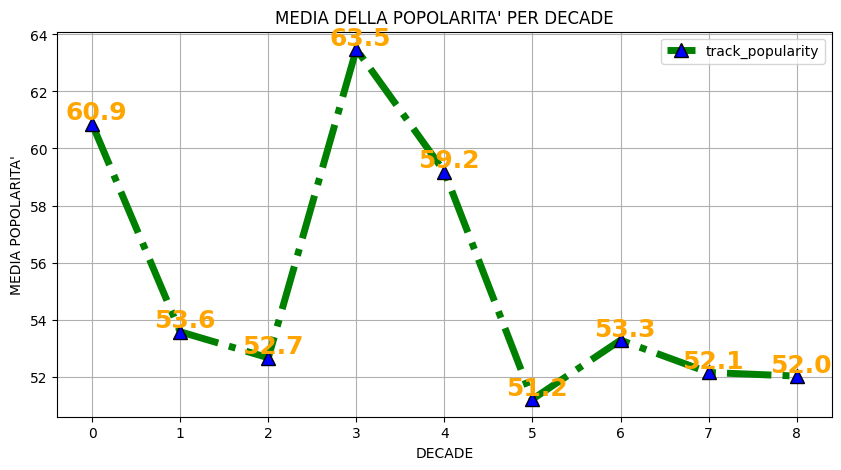

In [31]:
graficoTRACK = dfspotifymanipulationTRACK.plot(
    kind='line',
    y='track_popularity',
    figsize=(10,5),
    title='MEDIA DELLA POPOLARITA\' PER DECADE',
    grid=True,

    color='green',
    linewidth=5,
    linestyle="dashdot",
    marker='^',
    markeredgecolor='black', #COLORE BORDO MARKER
    markerfacecolor='blue',
    markersize=10,
    xlabel='DECADE',
    ylabel='MEDIA POPOLARITA\''
)
#INSERIRE ETICHETTE SUI MARKER
#for i, row in df.head(80).iterrows():  # df.head(80): Prende prime 10 righe (evita sovraffollamento) - iterrows(): Itera su ogni riga restituendo (indice, riga)
for index, row in dfspotifymanipulationTRACK.iterrows(): #interrows() SCORRE LE RIGHE DEL DATAFRAME
    graficoTRACK.annotate( #annota grafico per ogni riga del DataFrame
        f'{row["track_popularity"]:.1f}', # TESTO f'...' - prendi il valore B dalla riga row["track_popularity"] - con solo 1 decimale :(,1f)
        (row.name, row['track_popularity']), #POSIZIONE x=index row.name, y=valore della riga track_popularity row['track_popularity']
        xytext=(3,3),  #OFFSET +3px a destra , +3px in alto
        textcoords='offset points', # OFFSET in Pixel dal marker
        ha='center', #ALLINEAMENTO testo ancorato a centro - left center right
        fontsize=18, #DIMENSIONE FONT 18pt
        color='orange', #COLORE DELLE ETICHETTE
        fontstyle='normal', #STILE DELLE ETICHETTE 'normal' 'italic' 'uppercase'
        fontweight='bold', #GROSSEZZA DEL FONT 'light' 'normal' 'bold'
    )
#INSERIRE ETICHETTE SUI MARKER
plt.show()

#### track_popularity e anno

In [32]:
dfspotifymanipulationTRACKANNO=dfspotifymanipulation.groupby('anno')['track_popularity'].mean()
dfspotifymanipulationTRACKANNO=dfspotifymanipulationTRACKANNO.reset_index()  #RESETTO INDEX
dfspotifymanipulationTRACKANNO

,anno,track_popularity
0,1900,60.857143
1,1952,45.000000
2,1958,55.000000
3,1959,55.000000
4,1960,47.000000
...,...,...
64,2021,52.593679
65,2022,50.878205
66,2023,52.189655
67,2024,53.625585


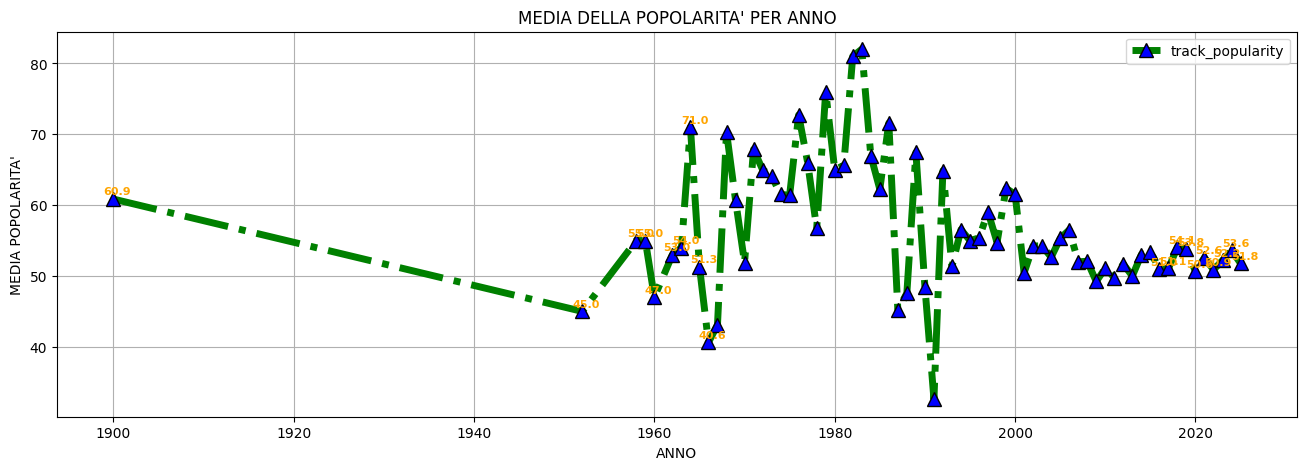

In [33]:
graficoTRACKANNO = dfspotifymanipulationTRACKANNO.plot(
    kind='line',
    y='track_popularity',
    x='anno',
    figsize=(16,5),
    title='MEDIA DELLA POPOLARITA\' PER ANNO',
    grid=True,

    color='green',
    linewidth=5,
    linestyle="dashdot",
    marker='^',
    markeredgecolor='black', #COLORE BORDO MARKER
    markerfacecolor='blue',
    markersize=10,
    xlabel='ANNO',
    ylabel='MEDIA POPOLARITA\''
)
#INSERIRE ETICHETTE SUI MARKER
#for i, row in df.head(80).iterrows():  # df.head(80): Prende prime 10 righe (evita sovraffollamento) - iterrows(): Itera su ogni riga restituendo (indice, riga)
for index, row in dfspotifymanipulationTRACKANNO.head(10).iterrows(): #interrows() SCORRE LE RIGHE DEL DATAFRAME
    graficoTRACKANNO.annotate( #annota grafico per ogni riga del DataFrame
        f'{row["track_popularity"]:.1f}', # TESTO f'...' - prendi il valore B dalla riga row["track_popularity"] - con solo 1 decimale :(,1f)
        (row['anno'], row['track_popularity']), #POSIZIONE x=index row.name, y=valore della riga track_popularity row['track_popularity']
        xytext=(3,3),  #OFFSET +3px a destra , +3px in alto
        textcoords='offset points', # OFFSET in Pixel dal marker
        ha='center', #ALLINEAMENTO testo ancorato a centro - left center right
        fontsize=8, #DIMENSIONE FONT 18pt
        color='orange', #COLORE DELLE ETICHETTE
        fontstyle='normal', #STILE DELLE ETICHETTE 'normal' 'italic' 'uppercase'
        fontweight='bold', #GROSSEZZA DEL FONT 'light' 'normal' 'bold'
    )
for index, row in dfspotifymanipulationTRACKANNO.tail(10).iterrows(): #interrows() SCORRE LE RIGHE DEL DATAFRAME
    graficoTRACKANNO.annotate( #annota grafico per ogni riga del DataFrame
        f'{row["track_popularity"]:.1f}', # TESTO f'...' - prendi il valore B dalla riga row["track_popularity"] - con solo 1 decimale :(,1f)
        (row['anno'], row['track_popularity']), #POSIZIONE x=index row.name, y=valore della riga track_popularity row['track_popularity']
        xytext=(3,3),  #OFFSET +3px a destra , +3px in alto
        textcoords='offset points', # OFFSET in Pixel dal marker
        ha='center', #ALLINEAMENTO testo ancorato a centro - left center right
        fontsize=8, #DIMENSIONE FONT 18pt
        color='orange', #COLORE DELLE ETICHETTE
        fontstyle='normal', #STILE DELLE ETICHETTE 'normal' 'italic' 'uppercase'
        fontweight='bold', #GROSSEZZA DEL FONT 'light' 'normal' 'bold'
    )
#INSERIRE ETICHETTE SUI MARKER
plt.show()

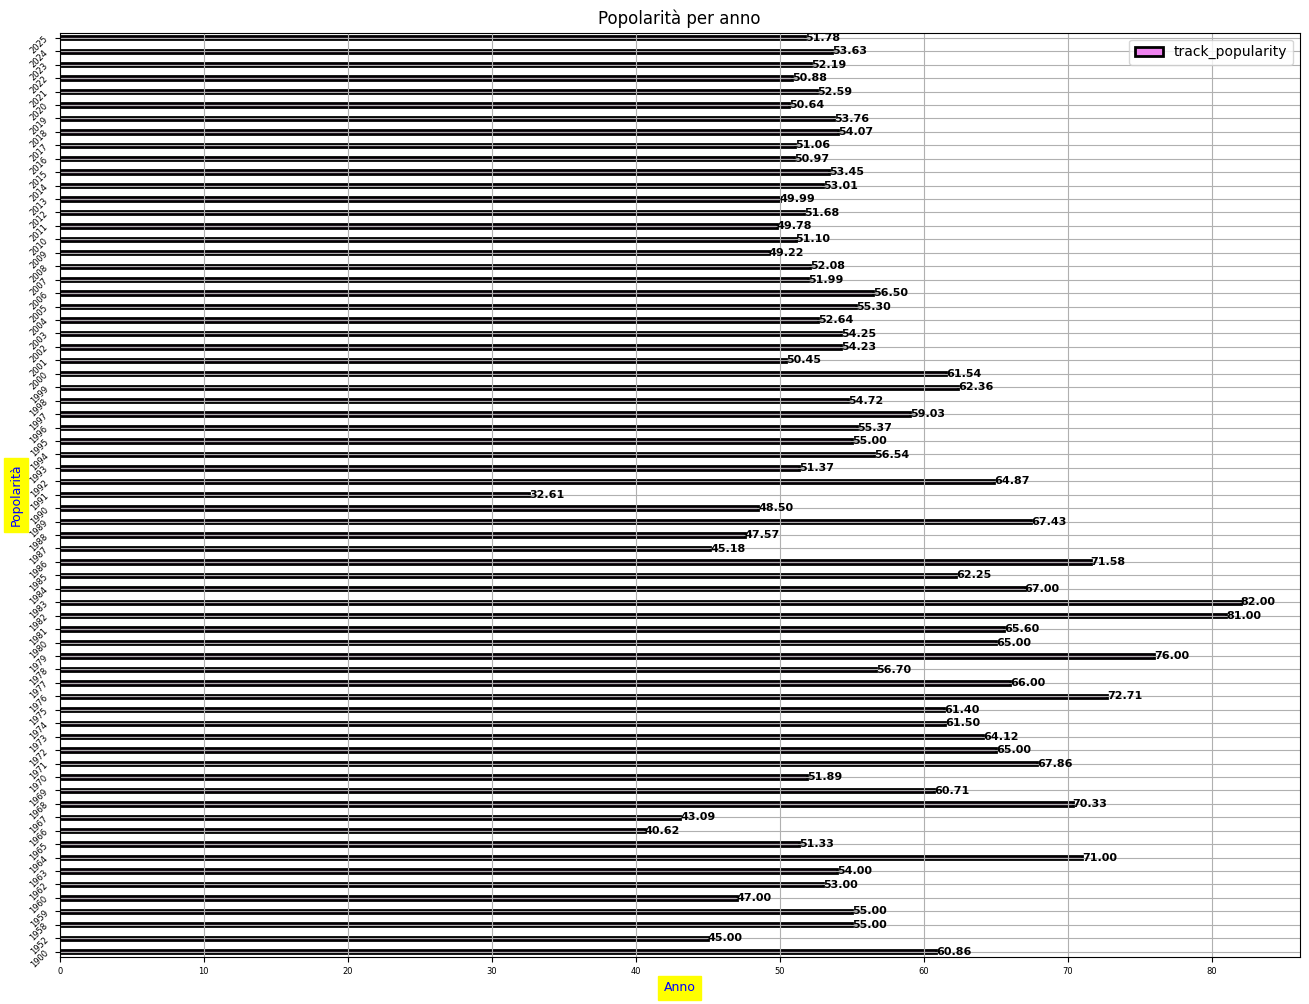

In [70]:
graficoTRACKANNOBAR=dfspotifymanipulationTRACKANNO.plot(
    kind='barh',
    y='track_popularity',
    x='anno',

    figsize=(16,12),
    grid=True,
    legend=True,

    color='violet',
    edgecolor='black',
    linewidth=2,
    width=0.25,

    title="Popolarità per anno",
    #xlabel='anno',
    #ylabel='Popolarità',
    rot=45,
    fontsize= 6
)
graficoTRACKANNOBAR.set_xlabel('Anno',color='blue',fontsize='9',backgroundcolor='yellow')
graficoTRACKANNOBAR.set_ylabel('Popolarità',color='blue',fontsize='9',backgroundcolor='yellow')
# Etichette barre
for container in graficoTRACKANNOBAR.containers:
        graficoTRACKANNOBAR.bar_label(
            container, 
            fmt='%.2f', # IL VALORE
            fontsize=8, 
            fontweight='bold',
            color='black'
        )

    
plt.show()

### 4.2. Produzione artistica per artista


In [40]:
dfspotifymanipulationARTISTTRACK=dfspotifymanipulation.groupby('artist_name')[['track_id','album_id']].count()
dfspotifymanipulationARTISTTRACK=dfspotifymanipulationARTISTTRACK.reset_index()
# Sostituire un carattere specifico $
dfspotifymanipulationARTISTTRACK['artist_name']=dfspotifymanipulationARTISTTRACK['artist_name'].str.replace('$',' ')
# Ordine per count track id
dfspotifymanipulationARTISTTRACK = dfspotifymanipulationARTISTTRACK.sort_values(
    by='track_id',
    ascending=False
)
dfspotifymanipulationARTISTTRACK

,artist_name,track_id,album_id
2120,Taylor Swift,324,324
2221,The Weeknd,141,141
1236,Lana Del Rey,99,99
145,Ariana Grande,94,94
1600,Nirvana,91,91
...,...,...,...
8,2 VIVE,1,1
9,2'Live Bre,1,1
14,3OH!3,1,1
15,4 Non Blondes,1,1


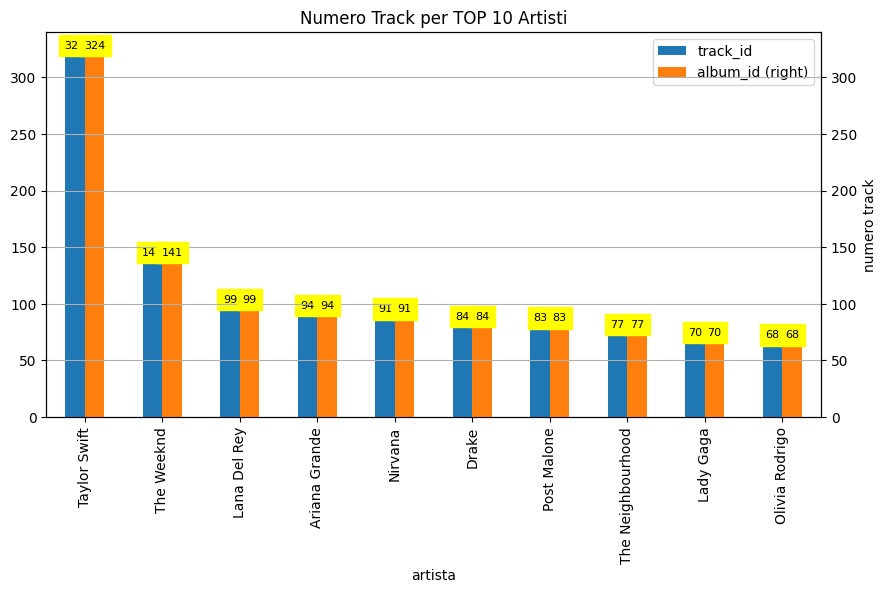

In [46]:
graficoTRACKARTIST=dfspotifymanipulationARTISTTRACK.head(10).plot(
    kind='bar',
    secondary_y='album_id',  
    x='artist_name',
    stacked=False,
    grid=True,
    legend=True,
    figsize=(10,5),
    xlabel='artista',
    ylabel='numero track',
    title='Numero Track per TOP 10 Artisti'
)
# Etichette barre
for container in graficoTRACKARTIST.containers:
        graficoTRACKARTIST.bar_label(
            container, 
            fmt='%g', # IL VALORE
            fontsize=8, 
            fontweight='normal',
            color='black',
            backgroundcolor='yellow'
        )
# Etichette barre
ax2=graficoTRACKARTIST.right_ax
for container in ax2.containers:
       ax2.bar_label(
            container, 
            fmt='%g', # IL VALORE
            fontsize=8, 
            fontweight='normal',
            color='black',
            backgroundcolor='yellow'
        ) 
plt.show()

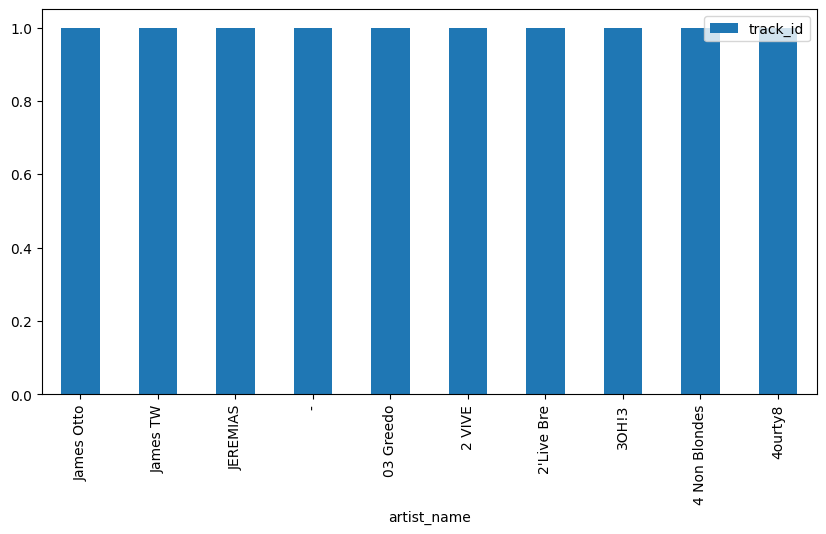

In [47]:
graficoTRACKARTIST=dfspotifymanipulationARTISTTRACK.tail(10).plot(
    kind='bar',
    y='track_id',
    x='artist_name',
    figsize=(10,5)
)
plt.show()

In [48]:
dfspotifymanipulationARTISTTRACK

,artist_name,track_id,album_id
2120,Taylor Swift,324,324
2221,The Weeknd,141,141
1236,Lana Del Rey,99,99
145,Ariana Grande,94,94
1600,Nirvana,91,91
...,...,...,...
8,2 VIVE,1,1
9,2'Live Bre,1,1
14,3OH!3,1,1
15,4 Non Blondes,1,1


In [49]:
#IMPOSTO ASSI
dfspotifymanipulationARTISTTRACKINDEX=dfspotifymanipulationARTISTTRACK.head(7).set_index('artist_name')
dfspotifymanipulationARTISTTRACKINDEX

,track_id,album_id
artist_name,,
Taylor Swift,324,324
The Weeknd,141,141
Lana Del Rey,99,99
Ariana Grande,94,94
Nirvana,91,91
Drake,84,84
Post Malone,83,83


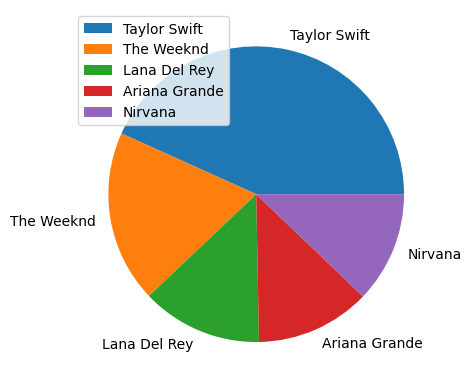

In [50]:
graficoTRACKARTISTPIE=dfspotifymanipulationARTISTTRACKINDEX.head(5).plot(
    kind='pie',
    y='track_id'
)
plt.show()

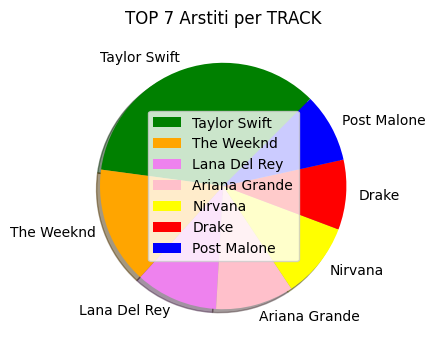

In [51]:
graficoPIE1 = dfspotifymanipulationARTISTTRACKINDEX.plot(
    kind='pie',
    y='track_id',

    figsize=(4,4),
    title='TOP 7 Arstiti per TRACK',
    legend=True,

    # CARATTERISTE ATTRIBUTI PER QUESTO GRAFICO
    startangle=45, #DA QUALE ANGOLAZIONE PARTIRE IN GRADI
    shadow=True, #EFFETTO OMBRA 3D
    colors=['green','orange','violet','pink','yellow','red','blue'], #COLORI DELLE FETTE
    #explode=[0.5,0.5,0.5,0.5,0.5,0.5,0.5] #DISTANZA FETTE
)
plt.show()

In [52]:
dfspotifymanipulationARTISTTRACKINDEXALL=dfspotifymanipulationARTISTTRACK.set_index('artist_name')

#CANCELLO DROP COLONNE
dfspotifymanipulationARTISTTRACKINDEXALLSOLO=dfspotifymanipulationARTISTTRACKINDEXALL.drop(columns=['album_id'])

dfspotifymanipulationARTISTTRACKINDEXALLSOLO.median()
dfspotifymanipulationARTISTTRACKINDEXALLSOLO.info

<bound method DataFrame.info of                track_id
artist_name            
Taylor Swift        324
The Weeknd          141
Lana Del Rey         99
Ariana Grande        94
Nirvana              91
...                 ...
2 VIVE                1
2'Live Bre            1
3OH!3                 1
4 Non Blondes         1
4ourty8               1

[2546 rows x 1 columns]>

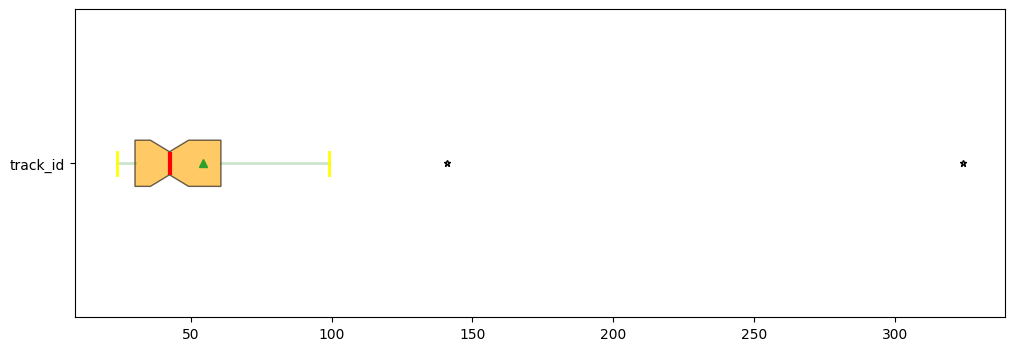

In [53]:
graficoTRACKBOX=dfspotifymanipulationARTISTTRACKINDEXALLSOLO.head(50).plot(
    kind='box',
    figsize=(12,4),
    vert=False,
    patch_artist=True,
    showmeans=True, # MOSTRARE LA MEDIA
    notch=True, #TACCHE MEDIANA
    flierprops=dict(marker='*', markersize=5, markerfacecolor='pink'),
    capprops=dict(color='yellow', linewidth=2 ), # MINIMO E MASSIMO
    boxprops=dict(facecolor='orange', alpha=0.6), #COLORE BOX
    medianprops=dict(color='red',  linewidth=3), #COLORE MEDIANA
    whiskerprops=dict(color='green', alpha=0.2, linewidth=2), # COLORE LINEE
)
plt.show()

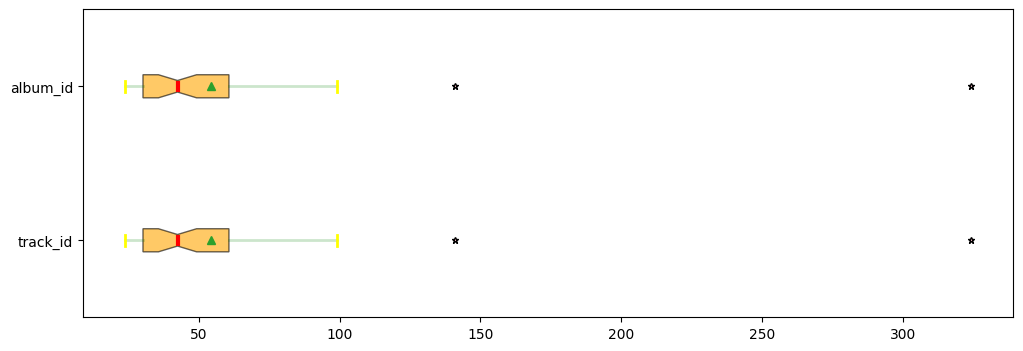

In [54]:
graficoTRACKBOX=dfspotifymanipulationARTISTTRACKINDEXALL.head(50).plot(
    kind='box',
    figsize=(12,4),
    vert=False,
    patch_artist=True,
    showmeans=True, # MOSTRARE LA MEDIA
    notch=True, #TACCHE MEDIANA
    flierprops=dict(marker='*', markersize=5, markerfacecolor='pink'),
    capprops=dict(color='yellow', linewidth=2 ), # MINIMO E MASSIMO
    boxprops=dict(facecolor='orange', alpha=0.6), #COLORE BOX
    medianprops=dict(color='red',  linewidth=3), #COLORE MEDIANA
    whiskerprops=dict(color='green', alpha=0.2, linewidth=2), # COLORE LINEE
)
plt.show()

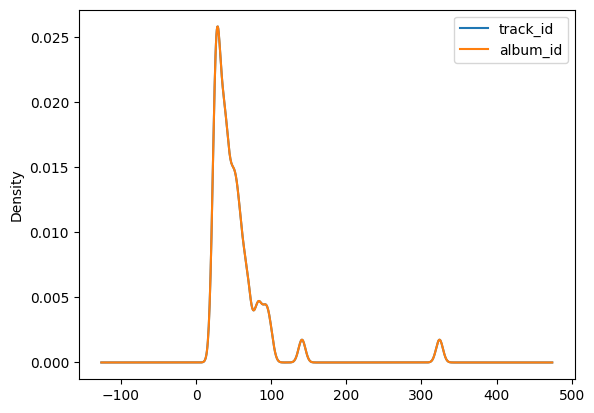

In [55]:
GRAFICOKDE=dfspotifymanipulationARTISTTRACKINDEXALL.head(50).plot(
    kind='kde',
    bw_method=0.1, # 0.1=ONDULATO - 1=LISCIO
)

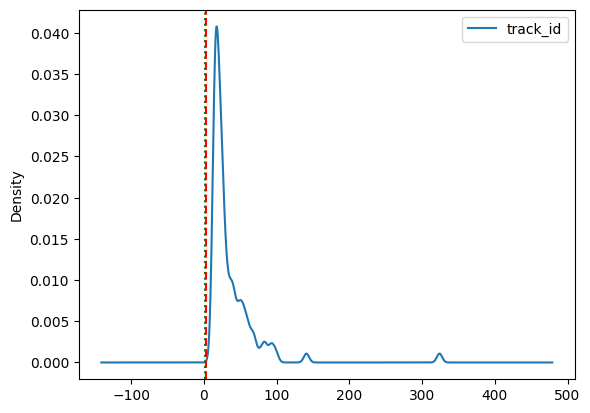

In [56]:
GRAFICOKDE=dfspotifymanipulationARTISTTRACKINDEXALL['track_id'].head(100).plot(
    kind='kde',
    bw_method=0.1, # 0.1=ONDULATO - 1=LISCIO,
    legend=True
)
#MEDIA E MEDIANA
mediaTRACK=dfspotifymanipulationARTISTTRACKINDEXALL['track_id'].mean()
medianaTRACK=dfspotifymanipulationARTISTTRACKINDEXALL['track_id'].median()
#VIEW MEDIA
GRAFICOKDE.axvline(mediaTRACK, color='red', linestyle='--', label='Media')
#VIEW MEDIANA
GRAFICOKDE.axvline(medianaTRACK, color='green', linestyle='dotted', label='Mediana')

plt.show()

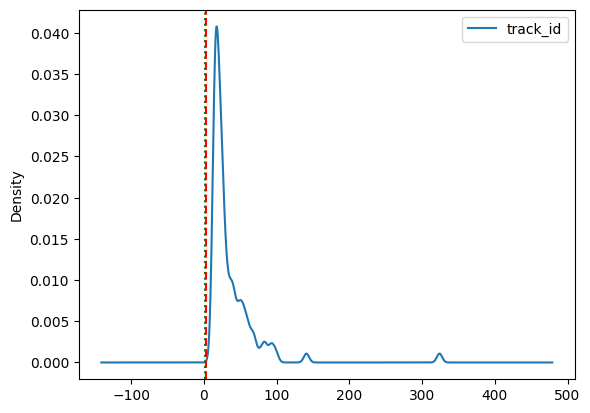

In [57]:
GRAFICOKDE=dfspotifymanipulationARTISTTRACKINDEXALL['track_id'].head(100).plot(
    kind='density',
    bw_method=0.1, # 0.1=ONDULATO - 1=LISCIO,
    legend=True
)
#MEDIA E MEDIANA
mediaTRACK=dfspotifymanipulationARTISTTRACKINDEXALL['track_id'].mean()
medianaTRACK=dfspotifymanipulationARTISTTRACKINDEXALL['track_id'].median()
#VIEW MEDIA
GRAFICOKDE.axvline(mediaTRACK, color='red', linestyle='--', label='Media')
#VIEW MEDIANA
GRAFICOKDE.axvline(medianaTRACK, color='green', linestyle='dotted', label='Mediana')

plt.show()

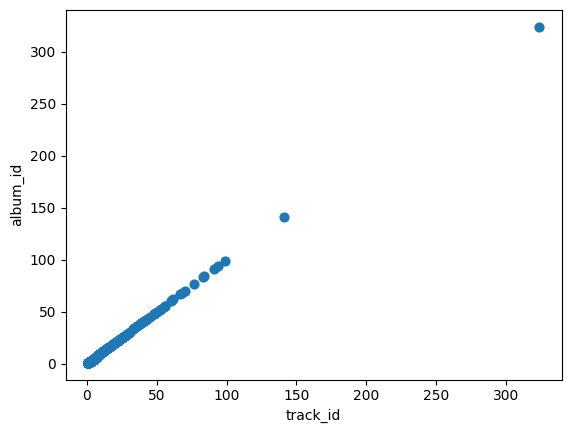

In [58]:
GRAFICOSCATTER=dfspotifymanipulationARTISTTRACKINDEXALL.plot(
    kind='scatter',
    x='track_id',
    y='album_id',
    s=40,                   # ← Dimensione punti
)
plt.show()

#### ARTIST CON TRACK, ALBUM E FOLLOWERS 'artist_popularity'

In [59]:
dfspotifymanipulationARTISTTRACKFOLL=dfspotifymanipulation.groupby('artist_name').agg(
    track_number=('track_id','count'),
    album_number=('album_id','count'),
    popularity_mean=('artist_popularity','mean')
)
dfspotifymanipulationARTISTTRACKFOLL=dfspotifymanipulationARTISTTRACKFOLL.reset_index()
# Sostituire un carattere specifico $
dfspotifymanipulationARTISTTRACKFOLL['artist_name']=dfspotifymanipulationARTISTTRACKFOLL['artist_name'].str.replace('$',' ')
# Ordine per count track id
dfspotifymanipulationARTISTTRACKFOLL = dfspotifymanipulationARTISTTRACKFOLL.sort_values(
    by='track_number',
    ascending=False
)
dfspotifymanipulationARTISTTRACKFOLL

,artist_name,track_number,album_number,popularity_mean
2120,Taylor Swift,324,324,100.000000
2221,The Weeknd,141,141,93.326241
1236,Lana Del Rey,99,99,88.000000
145,Ariana Grande,94,94,90.000000
1600,Nirvana,91,91,81.000000
...,...,...,...,...
8,2 VIVE,1,1,31.000000
9,2'Live Bre,1,1,32.000000
14,3OH!3,1,1,61.000000
15,4 Non Blondes,1,1,65.000000


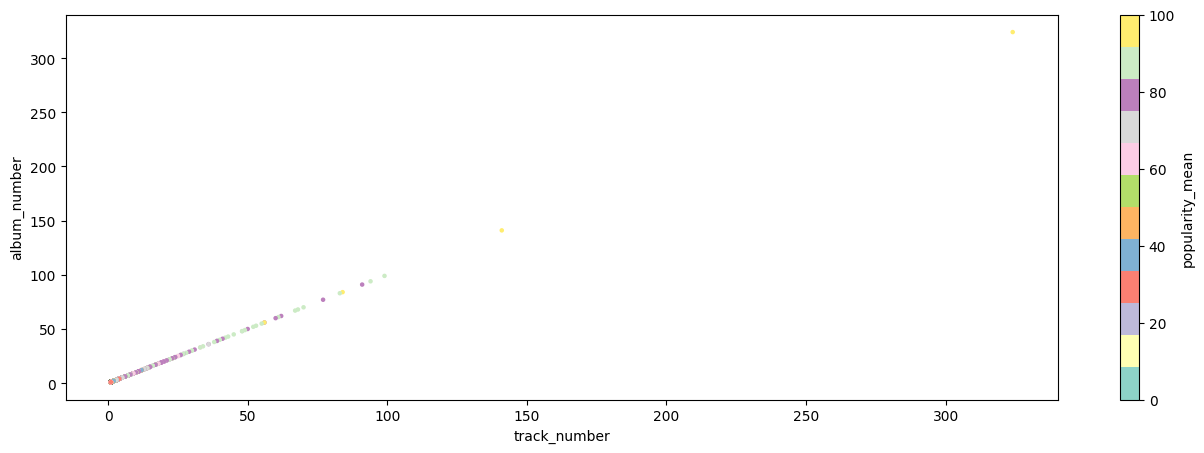

In [60]:
GRAFICOSCATTER1=dfspotifymanipulationARTISTTRACKFOLL.plot(
    kind='scatter',
    x='track_number',
    y='album_number',
    c='popularity_mean', # COLORO I PUNTI IN BASE ALLA POPOLARITA' MEDIA
    s=5,       
    figsize=(16,5),
    cmap='Set3'            
)
plt.show()

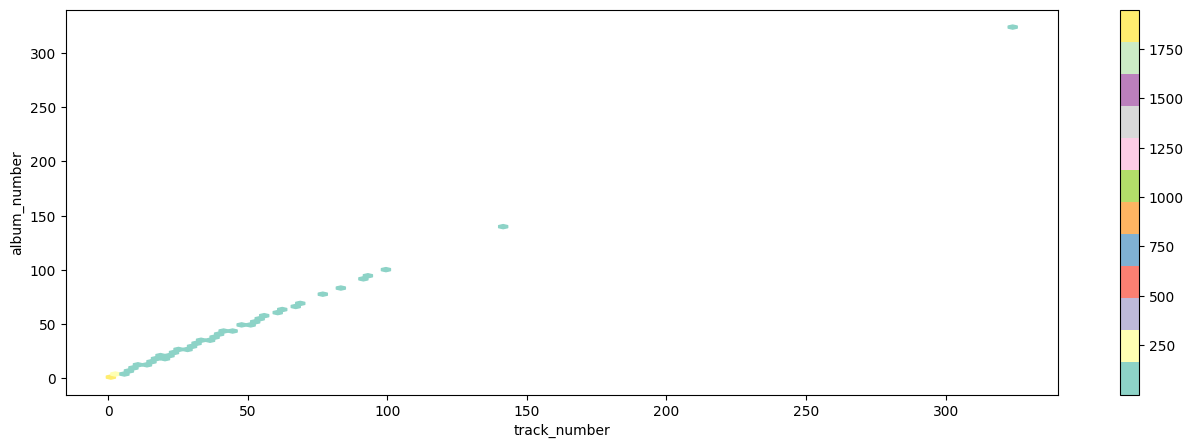

In [61]:
GRAFICOHEXBIN1=dfspotifymanipulationARTISTTRACKFOLL.plot(
    kind='hexbin',
    x='track_number',
    y='album_number',     
    figsize=(16,5),
    cmap='Set3',
    mincnt=1            
)
plt.show()

In [62]:
dfspotifymanipulationARTISTTRACKFOLL = dfspotifymanipulationARTISTTRACKFOLL.tail(1000).sort_values(
    by='popularity_mean',
    ascending=False
)
dfspotifymanipulationARTISTTRACKFOLL.head(300)

,artist_name,track_number,album_number,popularity_mean
1795,Rauw Alejandro,1,1,88.0
1706,Peso Pluma,1,1,86.0
1523,Myke Towers,1,1,85.0
141,Arcángel,1,1,82.0
1762,Quevedo,1,1,82.0
...,...,...,...,...
314,Brian Eno,1,1,60.0
2006,Slayyyter,1,1,60.0
192,BL8M,1,1,60.0
1686,Parov Stelar,1,1,60.0


### 4.3. Generi, Produzione e Popolarità

artist_genres, artist_popularity e track_id

In [63]:
dfspotifymanipulationGENRES=dfspotifymanipulation.groupby('artist_genres').agg(
    track_number=('track_number','count'),
    popularity_mean=('artist_popularity','mean'),
    artist_count=('artist_name','count')
)
dfspotifymanipulationGENRES=dfspotifymanipulationGENRES.reset_index()  #RESETTO INDEX

dfspotifymanipulationGENRES=dfspotifymanipulationGENRES.sort_values(
    by='popularity_mean',
    ascending=False
)

dfspotifymanipulationGENRES['artist_genres']=dfspotifymanipulationGENRES['artist_genres'].str.split(',').str[0:2]
dfspotifymanipulationGENRES['artist_genres']=dfspotifymanipulationGENRES['artist_genres'].apply(' - '.join)
dfspotifymanipulationGENRES.head(50)

,artist_genres,track_number,popularity_mean,artist_count
171,country - pop,324,100.000000,324
542,reggaeton - trap latino,56,95.000000,56
520,r&b pop - alternative r&b,141,93.326241,141
486,pop - contemporary r&b,55,91.000000,55
524,rap,187,90.481283,187
18,alternative pop - electropop,61,90.000000,61
488,pop - r&b,52,90.000000,52
148,corrido - corridos tumbados,2,89.000000,2
323,hip hop - west coast hip hop,11,89.000000,11
45,art pop - pop,70,88.271429,70


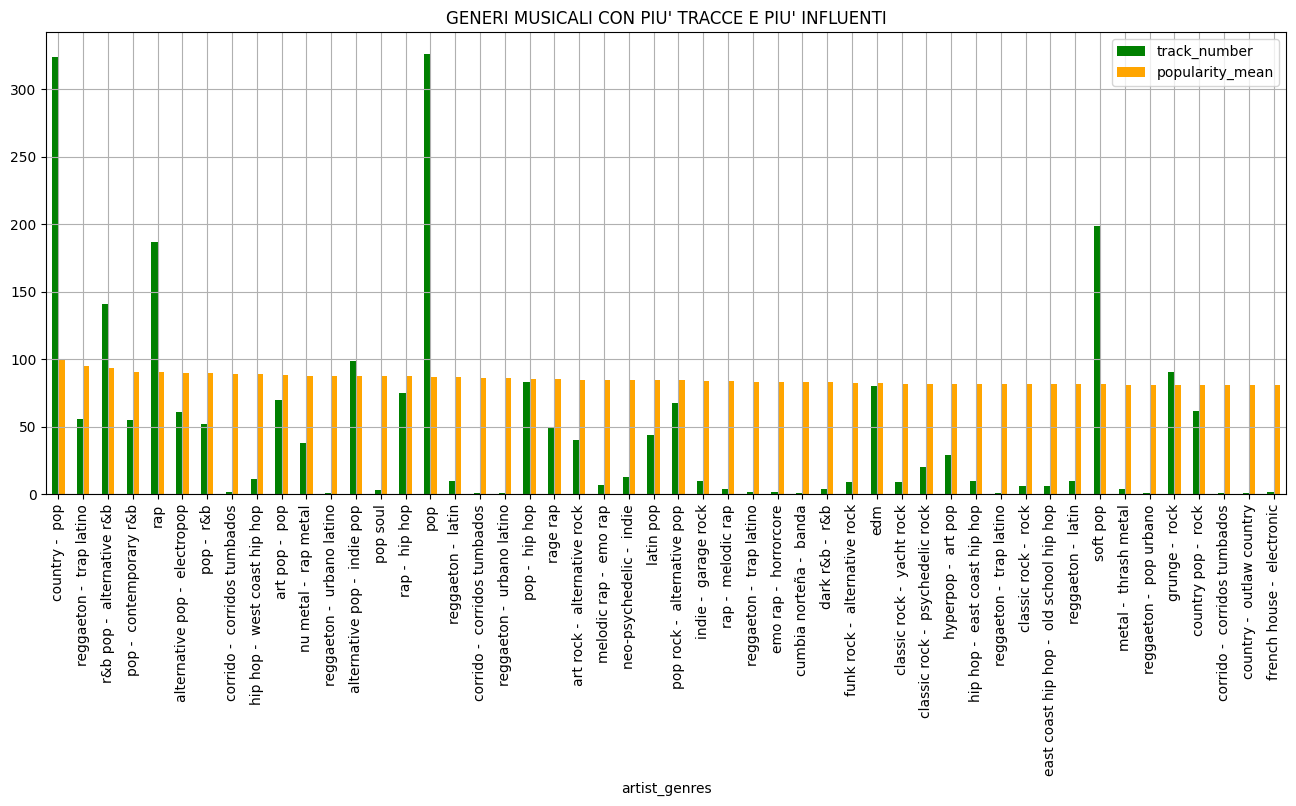

In [64]:
GRAFICOBAR1=dfspotifymanipulationGENRES.head(50).plot(
    kind='bar',
    figsize=(16,6),
    x='artist_genres',
    y=['track_number','popularity_mean'],
    grid=True,
    legend=True,
    color=['green','orange'],
    title='GENERI MUSICALI CON PIU\' TRACCE E PIU\' INFLUENTI'
)
plt.show()

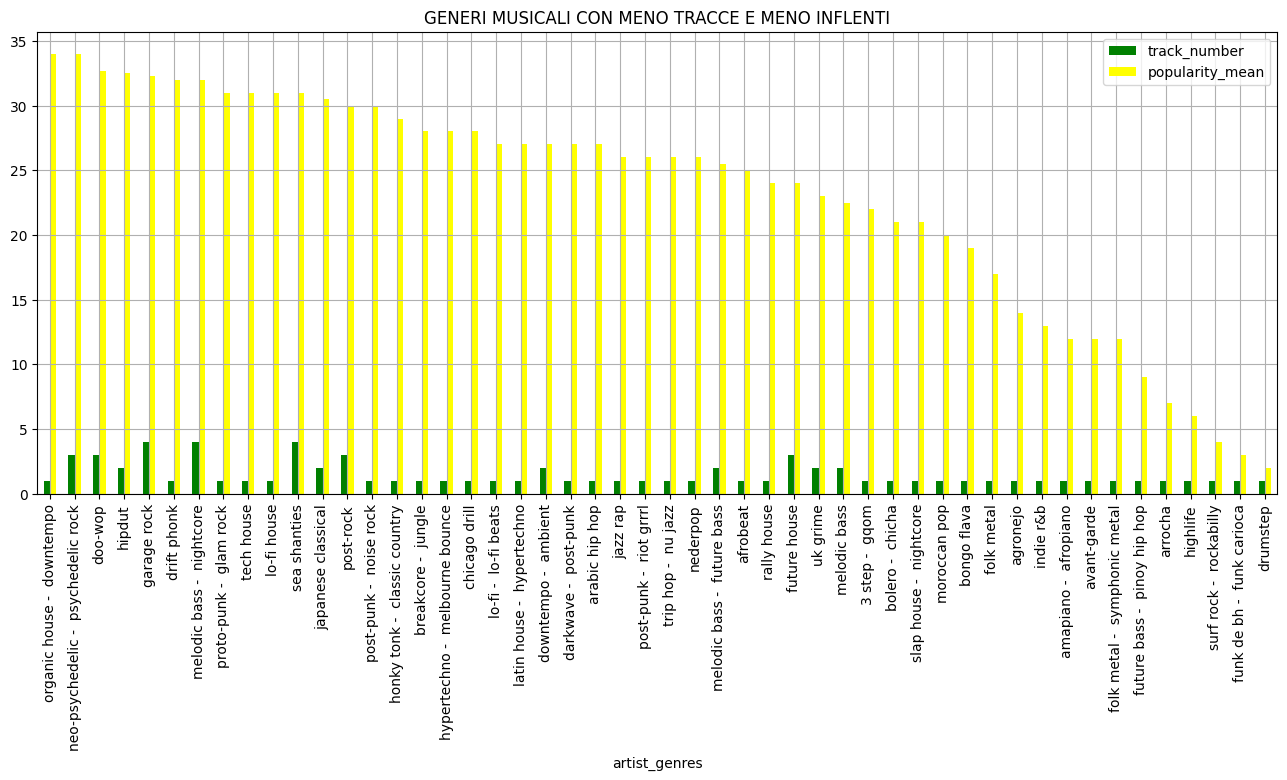

In [65]:
GRAFICOBAR2=dfspotifymanipulationGENRES.tail(50).plot(
    kind='bar',
    figsize=(16,6),
    x='artist_genres',
    y=['track_number','popularity_mean'],
    grid=True,
    legend=True,
    color=['green','yellow'],
    title='GENERI MUSICALI CON MENO TRACCE E MENO INFLENTI'
)
plt.show()

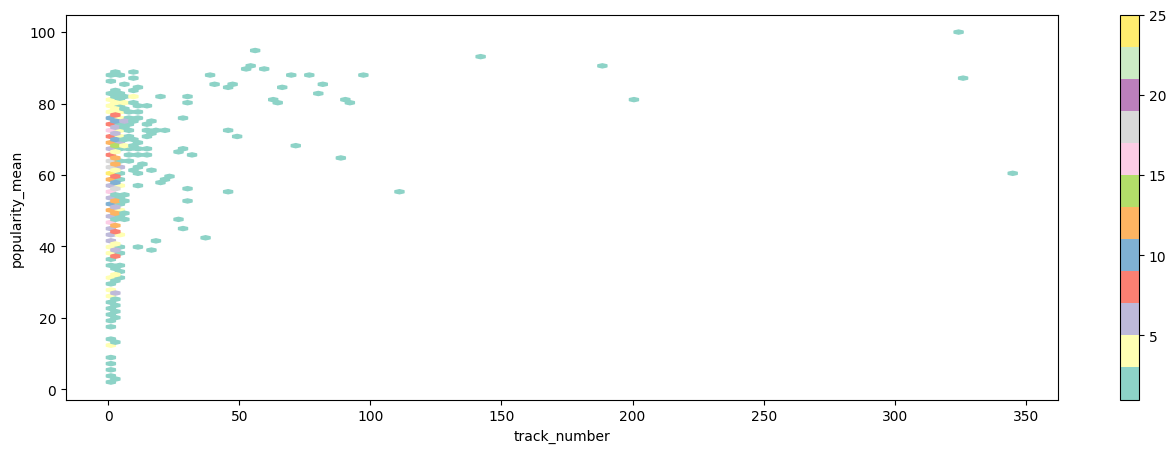

In [66]:
GRAFICOHEXBIN1=dfspotifymanipulationGENRES.plot(
    kind='hexbin',
    x='track_number',
    y='popularity_mean',
    figsize=(16,5),
    mincnt=1,
    cmap='Set3'
)

---
## 5. Conclusioni

L'analisi esplorativa del dataset Spotify (8.582 tracce, 18 variabili) ha portato alle seguenti conclusioni principali:

### 🎵 Popolarità e Tempo
- Le tracce degli **anni '80** (in particolare il 1983) risultano tra le più popolari su Spotify, probabilmente per la presenza di brani iconici ancora molto ascoltati oggi.
- Le canzoni delle **decadi più recenti** (2010–2020) mostrano una popolarità media più alta rispetto al passato, in linea con la maggiore presenza di utenti giovani sulla piattaforma.
- Le canzoni degli **anni '50** mostrano una popolarità media elevata per decade: questo è probabilmente un effetto statistico dovuto al basso numero di tracce disponibili di quell'epoca, dove solo i brani più celebri sono presenti nel dataset.

### 👩‍🎤 Artisti
- **Taylor Swift** è l'artista con la maggiore produzione musicale nel dataset, seguita da **The Weeknd**.
- Artisti emergenti con un solo album e poche tracce presentano spesso una **popolarità media superiore a 60**, suggerendo un forte impatto al debutto.
- Esiste una correlazione positiva tra il numero di tracce pubblicate e il numero di album, come atteso.

### 🎸 Generi Musicali
- Il genere **country, pop** domina per numero di tracce (oltre 300) e popolarità media prossima a 100.
- I generi con meno tracce tendono ad avere una popolarità media più bassa e variabile.

### 📌 Limitazioni e sviluppi futuri
- Il dataset non include dati aggiornati in tempo reale: i risultati riflettono uno snapshot storico.
- Un'analisi futura potrebbe approfondire le **caratteristiche audio** (danceability, energy, tempo) in relazione alla popolarità, applicando tecniche di machine learning per la previsione del successo di un brano.
